# TPC 239Pu(n,f)/235U(n,f) cs data preparation for GMA - UPDATE 4/15/2026

## Update 3/30/2026-4/15/2026:
- The Standards decided to treat fissionTPC data as shape.
- I think some part of the background uncertainty should be energy-dependent.


In [3]:
import os
from importlib import reload
from numpy import array, shape, diag, arange, ones, zeros, loadtxt, sqrt, meshgrid
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
homedir = os.getcwd() +'/'

In [5]:
cd ../../../src

/Users/dneudecker/Documents/Codes/ARIADNE-github/src


In [6]:
import Class_nfcs as Cnf
reload(Cnf)

<module 'Class_nfcs' from '/Users/dneudecker/Documents/Codes/ARIADNE-github/src/Class_nfcs.py'>

Text(0, 0.5, 'Relative Uncertainty (%)')

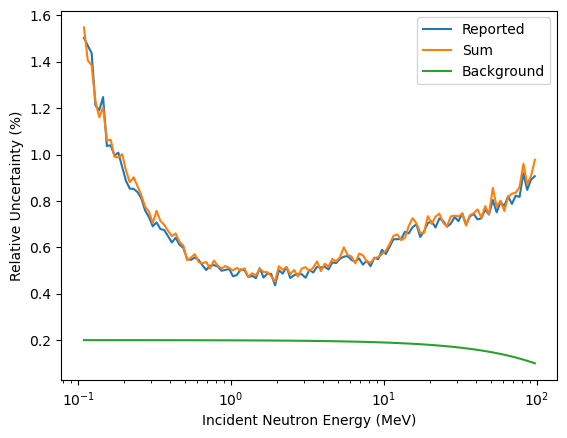

In [7]:
# update 4/15/2026 ------------------------------
forStandards = True

datafile = homedir+'fissionTPC_Pu239_U235_nf_Mean_Total.txt'
alldata  = loadtxt(datafile,skiprows=1)
Einc = alldata[:,0]+0.5*alldata[:,1]

count = 0
for index in arange(0,len(Einc)):
    count = count + 1
    if Einc[index] > 20.0:
        break

if forStandards:
    end = len(Einc)+1
else:
    end = count 
# -------------------------------------------------

# Data in here are all provided in private communication by Luke Snyder but are now in EXFOR.
Einc = alldata[:end,0]+0.5*alldata[:end,1] # The incident neutron energy is supplied
# in the form of a lower and upper bin edge. ARIADNE as well as GMA cannot deal 
# with that. Instead, an Einc per each data value needs to be supplied. I take
# the mid-point of the energy bin as this one-point energy. Luke oked that.
# checked that all partial uncertainties and Data are on the same grid.
# update 4/15/2026 ------------------------------
Einclow  = alldata[:end,0] # MeV
Einchigh = alldata[:end,1] # MeV
edgesE      = zeros(len(Einc) + 1,dtype=float)
edgesE[:-1] = Einclow
edgesE[-1]  = Einchigh[-1]
# For energy resolution.
# -------------------------------------------------

Data = alldata[:end,2] # shape Pu-239(n,f)/U-235(n,f), the data are normalized with
# their own normalization (sample mass and non-uniformity of beam/ sample and 
# beam overlap). However, they are systematically 2% off. Hence, the data
# will be treated as shape data in GMA. Hence, normalization uncertainties
# are ignored. (last column) Luke oked that.

Totunc = alldata[:end,3]*100.0/Data # The total uncertainties are given.
# Counter-check if the partial uncertainties add up.

datafile = homedir+'fissionTPC_Pu239_U235_nf_Partial_Uncertainty.txt'
alldata  = loadtxt(datafile,skiprows=1)

normunc_countstat_eff_spectrumfit = sqrt(0.058**2.0+0.007**2.0+0.102**2.0+0.078**2.0+\
                                            0.07**2.0)
normunc_massspec = sqrt(0.019**2.0+0.17**2.0)
normunc_halflife = sqrt(0.144**2.0+0.124**2.0)


# update 4/15/2026 ------------------------------
thermalbckgrd = ones(len(Einc),dtype=float)*0.1
for index in arange(0,len(Einc)):
    thermalbckgrd[index] = 0.1 + 0.1 * (max(Einc)-Einc[index])/(max(Einc)-min(Einc))


normunc_spacecharge = 0.85 # will not be used

normunc = sqrt(normunc_countstat_eff_spectrumfit**2.0+normunc_massspec**2.0+normunc_halflife**2.0+\
               normunc_spacecharge**2.0) # will not be used
# -------------------------------------------------

statunc = alldata[:end,1] # %, The statistical uncertainty is explicitly supplied
# by the experimentalist. 


deteffunc1 = alldata[:end,2] # %, The first detector efficiency uncertainty is the
# "variational" unc. which accounts for the variation in the PID cuts.
# The correlation matrix is varying around slightly positive and slightly 
# negative from 0.3-200 MeV. Below it is more positive. It will be a
# challenge to approximate that. 
# It is interesting to note that these variational (PSD cut) correlations 
# are closer to zero above 0.3 MeV, while the U-8/U-5 correlations for 
# this uncertainty source are more pronounced positive above 0.3 MeV.

background = alldata[:end,3] # %, The backrground uncertainty accounts for background
# correction uncertainties related to the wrap-around background. Background due to
# fission fragment recoils and a-particles is zero because they are clearly identified
# by PID cuts. The unc. in the variation of the PID cut is the variational unc. 
# The correlation matrix provided by R. Casperson is best approximated with a
# Gaussian anti-correlation with a turning point
# at Einc = 1.4545 MeV and a damping term of 1 in a visual comparison with
# that option of ARIADNE and the partial correlation matrix provided by R.
# Casperson.
# The shape wrap-around correlations of Pu-9/U-5 are similar to those of U-8/U-5, 
# although they are less strongly positive. This is curious in as far as I would 
# expect a similar wrap-around effect and correction for both measurements given 
# that you took them at the same facility? In the same vein, your wrap-around
# uncertainties seem smaller at high Eout than those in the PRC by Robert?

deteffunc2 = alldata[:end,4] #%, The second efficiency uncertainty accounts for uncertainties
# in the efficiency model such as in the SRIM stopping power assumption, FY unc., etc.,
# The correlation matrix is on average diagonal in a visual comparison with the partial
# correlation matrix provided by L. Snyder in private communication. Correlations 
# to other measurements could arise because of common usage of SRIM. However, the correlation
# matrix is diagonal to begin with. Even if it was not diagonal, only low Einc would be
# affected by the cross-correlations according to a discussion with R. Casperson.

impurity = alldata[:end,5] # %, The impurity uncertainty accounts for contaminations in
# the sample. The correlation matrix for U-5/U-8 was fully correlated in as provided 
# by Robert, while this one is closer to average correlations of 0.3. Is that because 
# you know the contamination level and nuclear (structure) data much better than the 
# alpha-counts??

overlap = alldata[:end,6] # %, beam-overlap uncertainties are nearly diagonal. My first 
# instinct would have been that they are fully correlated as it applies to the 
# whole measurement, but as Luke says in his journal article, the beam 
# overlap is Einc-dependent due to the beam. Is it also diagonal because 
# he effectively measures beam overlap by identifying alphas.

attenuation = alldata[:end,7] # %, attenuation uncertainties are explicitly
# given after asking for them. They are diagonal as they only encompass
# MC statistics uncertainties.

Totunc2= sqrt(overlap*overlap+impurity*impurity+deteffunc2*deteffunc2+\
deteffunc1*deteffunc1+statunc*statunc+background*background)#+alldata[:,8]*alldata[:,8])

plt.semilogx(Einc,Totunc)
plt.semilogx(Einc,Totunc2)
plt.semilogx(Einc,thermalbckgrd)
plt.legend(['Reported','Sum','Background'])
plt.xlabel('Incident Neutron Energy (MeV)')
plt.ylabel('Relative Uncertainty (%)')

In [8]:
# Information found in the paper:
TOFlength = 8.059 # m
TOFlength_unc = 3 # mm
trsl = 2.75/2.355 # ns. The time resolution is divided by
# a factor of 2.355 because it is given at FWHM rather 
# than the 1-sigma level. Oked by Luke

In [9]:
features = {"Author": ["L. Snyder","M. Anastasiou","N.S. Bowden","J. Bundgaard","R.J. Casperson","D.A. Cebra","T. Classen","D.H. Dongwi","N. Fotiades","J. Gearhart","V. Geppert-Kleinrath","U. Greife","C. Hagmann","M. Heffner","D. Hensle","D. Higgins","L.D. Isenhower","K. Kazkaz","A. Kemnitz","J. King","J.L. Klay","J. Latta","E. Leal-Cidoncha","W. Loveland","J.A. Magee","B. Manning","M.P. Mendenhall","M. Monterial","S. Mosby","D. Neudecker","C. Prokop","S. Sangiorgio","K.T. Schmitt","B. Seilhan","F. Tovesson","R.S. Towell","N. Walsh","T.S. Watson","L. Yao","W. Younes"],
"Year": "2021",
'Absolute':'n',\
"Facility": ['LINAC','SPALL','1USALAS'],
"Institute": ["1USALRL","1USACSM","1USADAV","1USALAS","1USAORU","1USAUSA"],
"Isotope": "Pu-239",
"Quantity": "cs", 'reaction': 'n,f',\
"MeasurementType": "Shape clean ratio",
"ConcernEXFOR": "None",
"ConcernPARADIGM": ["Wraparound","Overlap"],
"ConcernAIACHNE_text": ["Wraparound correction applied but might miss thermal background.","Beam overlap correction applied, but space-charge correction could not be verieifed within 0.85% at LANL and LLNL leading to that span-width of potnetial differences in cs."],
"BackgroundCorrected": "partial",
"AlphaBackground": "y",
"GammaBackground": "y",
"RandomCoincidenceBackground": "partial",
"ShadowBarBackground": "N/A",
"WrapAroundBackground": "y",
"MultipleScatteringSampleBackingCorrected": "y",
"MultipleScatteringSurroundingCorrected": "y",
"AttenuationSampleBackingCorrected": "y",
"AttenuationSurroundingCorrected": "y",
"FissionDetectionEfficiencyCorrected": "y",
"SampleDecayCorrected": "y",
"FissionFragmentAbsorptioninSampleCorrected": "y",
"SignalPulsePileupCorrected": "N/A",
"DeadtimeCorrected": "N/A",
"AngularDistributionFissionFragmentsCorrected": "y",
"ImpuritiesCorrected": "y",
"CorrelatedData": "Dongwi",
"EXFORnumber": "14721.002",
"Accepted": "y",
"MissingCorrections": ["ThermalBackground","RandomCoincidenceBackground"],
"FissionDetector": {
"Type": "TPC with MICROMEGAS",
"ParticleDetected": "FF",
"Efficiency": "unknown",
"EfficiencyMethod": ["unknown"],
"FFAbsorptionAngularDistributionMethod": "MC calculated",
"AngularAcceptaneofFF": "unknown",
"Gas": {"Type": "Ar + 5% iC4H10", "Purity": "unknown", "Pressure": "550 torr"},
"Size": {"geometry": "two cylindrical volumes; dimensions unknown"},
"NoPhotomultipliers": "N/A",
"Weight": "unknown",
"StructuralMaterial": "unknown",
"ReferenceDetector": ["MICROMEGAS readout; fast cathode timing"]
},
"NeutronDetector": {
"Type": "N/A (TOF start from accelerator RF; stop from TPC cathode)",
"Number": "N/A",
"ParticleDetected": "N/A",
"Efficiency": "N/A",
"ResponseDeterminationMethod": ["N/A"],
"EfficiencyDeterminationMethod": ["N/A"],
"Angle": "N/A",
"TOFLength": {"Value": 805.9, "Unit": "cm", "Unc": 0.3},
"trsl": {"Value": 2.75, "Unit": "ns", "Measure": "FWHM"},
"t0Determination": "accelerator signal",
"Gas": {"Type": "N/A", "Purity": "N/A", "Pressure": "N/A"},
"Size": {"geometry": "N/A"},
"NoPhotomultipliers": "N/A",
"Photomultipliers": "N/A",
"Weight": "N/A",
"StructuralMaterial": "N/A",
"ReferenceDetector": "N/A",
"ReferenceReaction": "N/A"
},
"Shielding": {"Material": "unknown", "Size": "unknown", "DistanceFromNeutronDetector": "N/A", "Purpose": "unknown"},
"Sample": {
"Activity": "N/A",
"Activity_unit": "N/A",
"Reused": "unknown",
"Form": "double-sided actinide target",
"Mass": "U: 90 µg/cm2 as UF4 (areal density); Pu: 118 µg/cm2 (areal density)",
"Diameter": 20.0,
"Thickness": "unknown",
"Homogenity": "unknown",
"Contaminants": "minor isotopic impurities noted",
"BackingMaterial": "Al (0.25 mm)",
"BackingDiameter": "unknown",
"BackingThickness": 0.25,
"DecayDeterminationMethod": "N/A",
"Configuration": "OneSample (double sided U/Pu)",
"Fabrication": "UF4 vacuum volatilized (U) and Pu molecular plated",
"Normalization":"N/A",
"ImpurityDetermination": "isotopic enrichment listed in EXFOR"
},
"ShadowBar": {"Used": "unknown", "Material": "unknown", "Size": "unknown", "Size_unit": "mm", "Material of structure holding it": "unknown"},
"OutgoingEnergyDetermination": "TOF",
"IndividualChannelWidthDetermination": "unknown",
"AverageChannelWidthDetermination": "Fission peak",
"BackgroundMethods": {
"General": "corrections applied as listed",
"Wraparound": "Calculated",
"alpha": "PSD",
"Gamma": "PSD",
"RandomCoincidence": "WrapAround"
},
"MultipleScatteringMethods": {"InSample": "MC", "Surrounding": ["MC"]},
"AttenuationMethods": {"InSample": "MC", "Surrounding": ["MC"]},
"DeadtimeDeterminationMethod": "N/A"
}



Testing covariance matrix of type Diagonal:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Constant:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Diagonal:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Constant:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Diagonal:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Diagonal:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

/Users/dneudecker/Documents/Codes/ARIADNE-github/
REFERENCE_LIBRARY_FILE: /Users/dneudecker/Documents/Codes/ARIADNE-github/Data/ReferenceData_dict.txt
{'isotope': 'Pu-239', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.1'}
{'i

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


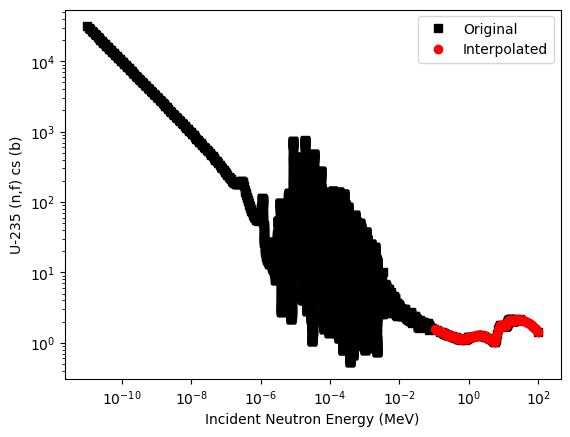

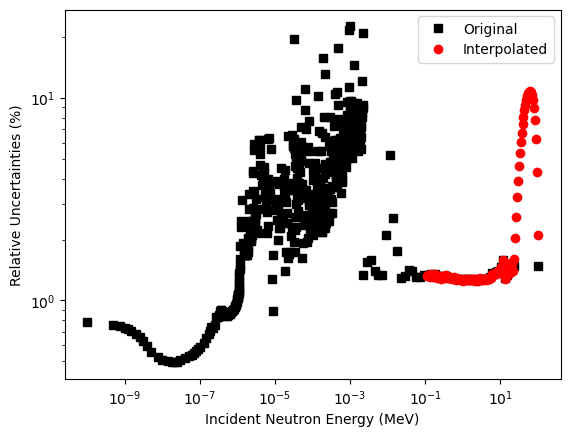

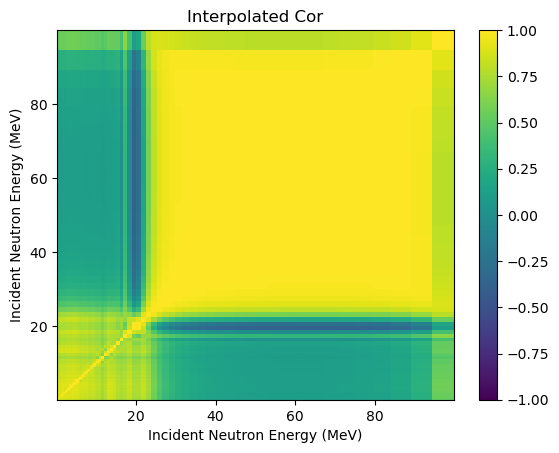

Testing interpolated covariance matrix of reference reaction:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing total covariance matrix:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

WIP: not yet included. No Xml file produced.

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Pu-239/nfcs_6001_Pu9U5TPC/DS6001.xml
{'isotope': 'Pu-239', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.1'}

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Pu-239/nfcs_6001_Pu9U5TPC/DS6001EUCLID.json
{'isotope': 'Pu-239', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.1'}
{'isotope': 'U-235', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.1'}

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Pu-239/nfcs_6001_Pu9U5TPC/DS6001ratiodataEUCLID.json

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-g

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


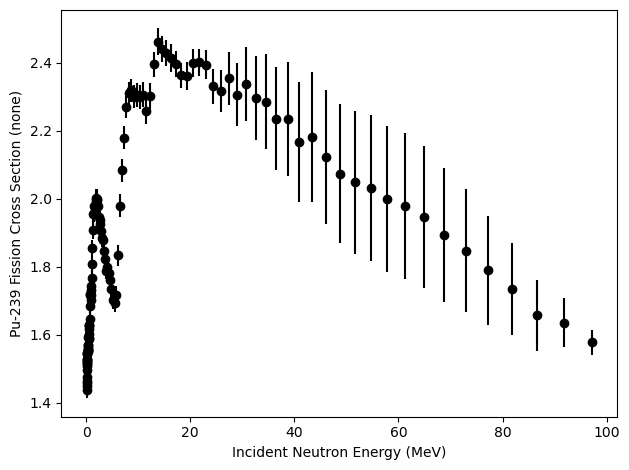

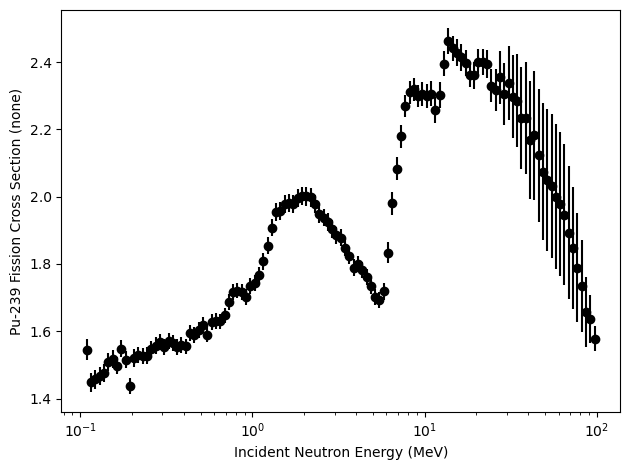

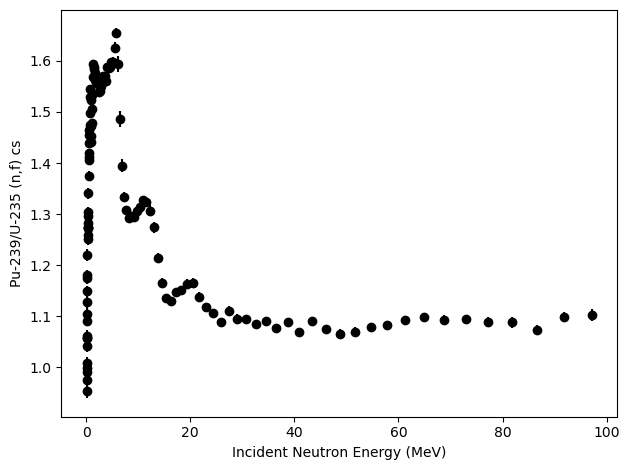

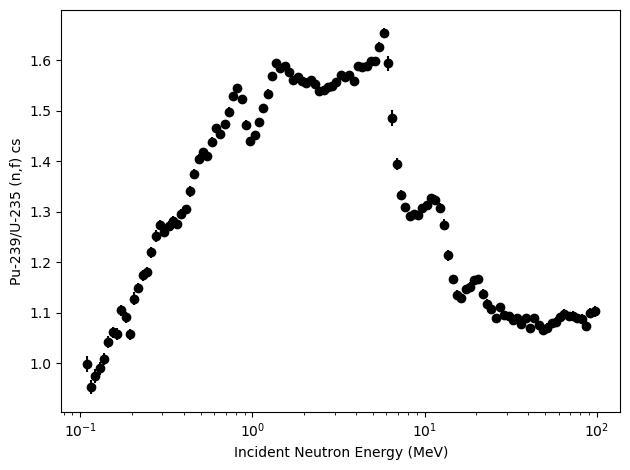

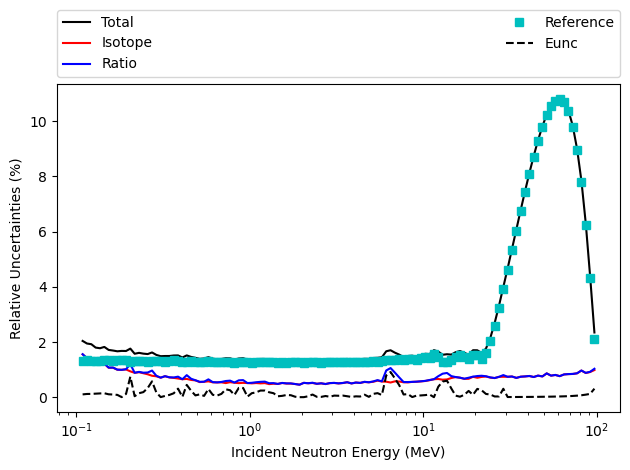

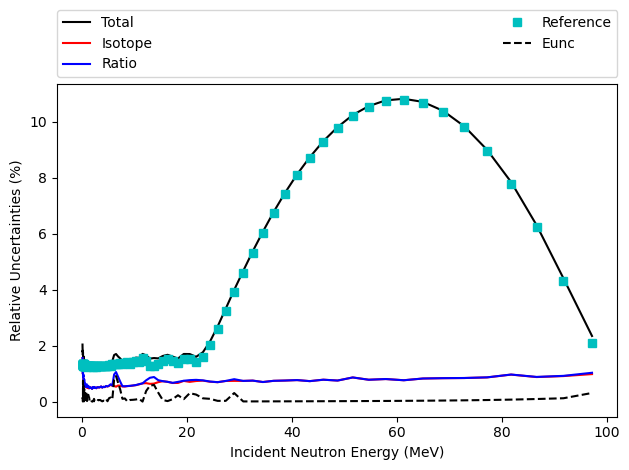

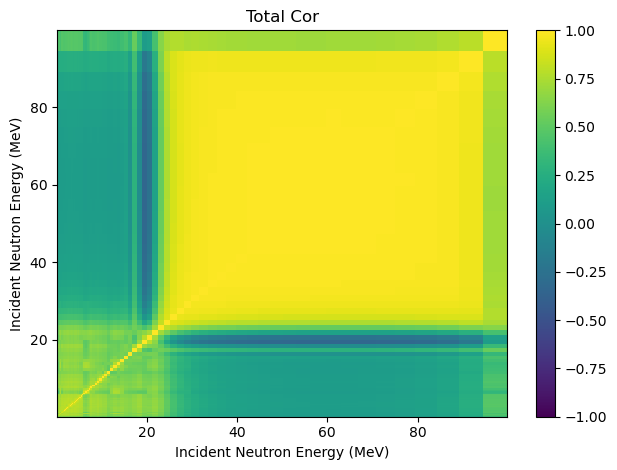

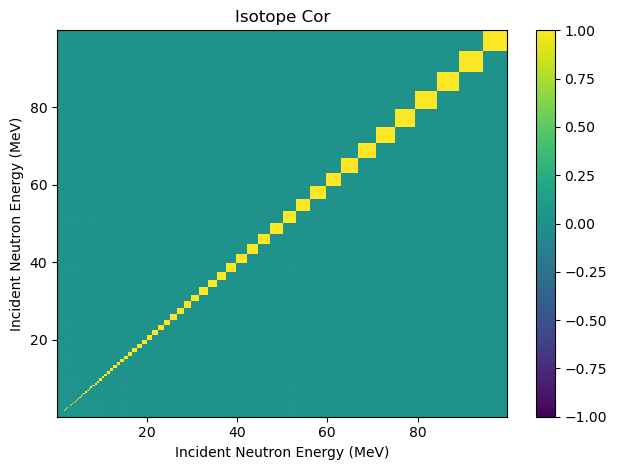

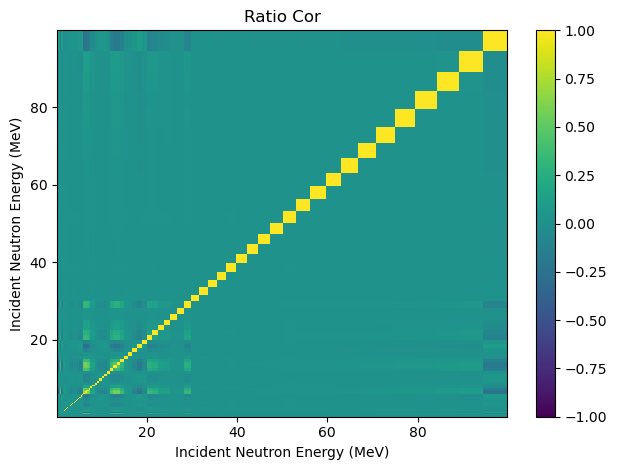

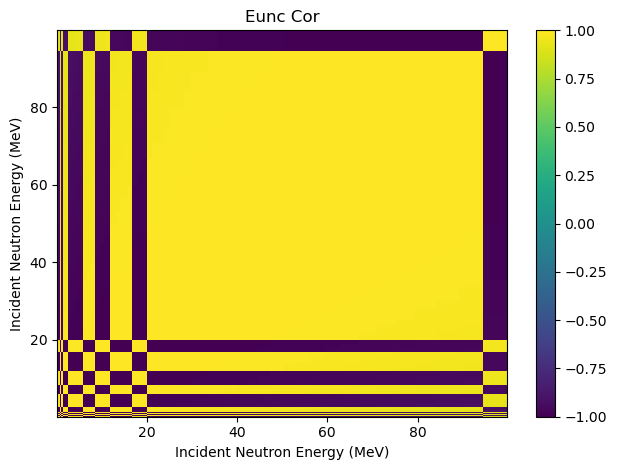

In [10]:
Documentation = """EXFOR No. = 14721002; the data are not yet in GMA, following the current numbering \
	and convention, I would assign D6001; Journal article = L. Snyer et al., NDS, to be  \
	submitted (2020). The data used in here are all provided in private communication by Luke \
 	Snyder. The incident neutron energy is supplied in the form of a lower and upper bin edge. \
	ARIADNE as well as GMA cannot deal with that. Instead, an Einc per each data value needs to \
 	be supplied. I take the mid-point of the energy bin as this one-point energy. This procedure \
 	was discussed with L. Snyder in private communication and he agreed that this is \
 	acceptable. The data are shape Pu-239(n,f)/U-235(n,f) data. They were normalized with \
    their own procedure but are systematically off by 2% compared to ENDF/B-VIII.0 \
    which they do not fully trust. So, the data will be treated as shape data in GMA. \
    The statistical uncertainty is explicitly supplied by the experimentalist and the \
    correlation matrix is assumed to be diagonal. The first detector efficiency uncertainty \
    is the "variational" unc. which accounts for the variation in the PID cuts. The \
    correlation matrix is constant with a factor of 0.15 in a visual comparison with \
    that option of ARIADNE and the partial correlation matrix provided by L. Snyder \
    (not perfect). The background uncertainty accounts for background correction uncertainties \
 	related to the wrap-around background. Background due to fission fragment recoils and alpha-\
	particles is zero because they are clearly identified by PID cuts. The unc. in the variation \
 	of the PID cut is the variational unc. The correlation matrix provided by L. Snyder is \
 	best approximated with a diagonal one in a visual comparison with that option of ARIADNE \
    and the partial correlation matrix provided by L. Snyder. The second efficiency uncertainty \
    accounts for uncertainties in the efficiency model such as in the SRIM stopping power assumption,\
    FY unc., etc., The correlation matrix is on average diagonal in a visual comparison with the partial \
	correlation matrix provided by L. Snyder in private communication. Correlations to other \
 	measurements could arise because of common usage of SRIM. However, the correlation matrix is \
 	diagonal to begin with. Even if it was not diagonal, only low Einc would be correlated due to \
	common usage of SRIM according to a discussion with R. Casperson (U-8/U-5). The impurity uncertainty \
 	accounts for contaminations in the sample. The correlation matrix is correlated with a factor of 0.35 in a \
 	visual comparison with the data provided by L. Snyder. This uncertainty could be \
 	correlated to other measurements due to usage of alpha-counting and related nuclear data. \
	No normalization unc. needs to be accounted for as this is treated as a shape measurement. Attenuation \
	and multiple scattering uncertainties are provided by L. Snyder and are diagonal (MC statistics,\
    only, no nuclear data unc. considered}. The FF angular \
    distribution uncertainty is part of the detector efficiency uncertainty. The energy \
    uncertainty is obtained by accounting for the TOF length unc. and trsl which is provided \
    in the journal article. The dead time uncertainty is zero according to L. Snyder\
    due to improved electronics. The beam-sample-overlap uncertainty is explicitly given \
    and provided by L. Snyder. It is energy-dependent and nearly diagonal, because it \
    was corrected with a measurement. Private communication took place by phone meeting\
    and e-mail exchange in the time-frame from late summer of 2020 to January of\
    2021, L. Snyder was involved in that exchange."""


general_info = {'name': 'DS6001', 'isotope': 'Pu-239', 'quantity': 'cs', 'reaction': 'n,f', \
                'output_file' : homedir+'DS6001.xml', \
                'output_folder' : homedir,\
                'documentation' : Documentation}

deltat_vsTOF = trsl*2.355*1.0e-9/(TOFlength) # assuming FWHM, DON'T CONVERT TO 1-SIGMA. THIS MUST BE FULL-WIDTH HALF-MAXIMUM!!!
nmass = 1.67492735174e-27 # kg
Energyconversionfactor = 1.60217653e-13
Ersl = 100.0*sqrt(8)*sqrt(Einc*Energyconversionfactor)*deltat_vsTOF/sqrt(nmass)

resolution = {'chw_edges': edgesE,
              'chw_edges_unit':'MeV',
              'tof_length':TOFlength,
              'tof_length_unit':'m',
              'energy_resolution': Ersl*Einc/100.0,
              'energy_resolution_unit': 'MeV'}

einc_unc = {'tof_length': {'value':  TOFlength ,'value_unit': 'm', 'unc': TOFlength_unc, 'unc_unit': 'cm'},\
            'en_err' : {'enerr_unc': array(Ersl*0.1/2.355),'enerr_unc_unit': '%','enerr_unc_type':'Positive_fully','enerr_unc_type_arg':{}},\
            'identifier_iso_deriv1' : 'ENDF/B-VIII.1','resolution':resolution}


norm_unc = {'value': normunc, 'unit':'%'}

reference = {'isotope': 'U-235','quantity': 'cs', 'reaction': 'n,f','identifier':'ENDF/B-VIII.1'}

unc_iso = {'einc_unc': einc_unc, \
           'values':array([statunc,deteffunc1,background,\
                           deteffunc2,impurity,overlap,attenuation]).transpose(),\
           'units':['%','%','%','%','%','%'],\
           'type':['Diagonal','Constant','Gaussian',\
                   'Diagonal','Constant','Diagonal','Diagonal'],\
            'type_arg':{'einc':array(Einc),'damp_term':[1.0,0.15,1.0,1.0,0.35,1.0,1.0]}}

data = {'einc': array(Einc), 'einc_unit': 'MeV', 'values':array(Data), 'values_unit': "none" }

DS6001_nfcs = Cnf.nfcs_cleanratioshape(general_info,data,unc_iso,reference,features)

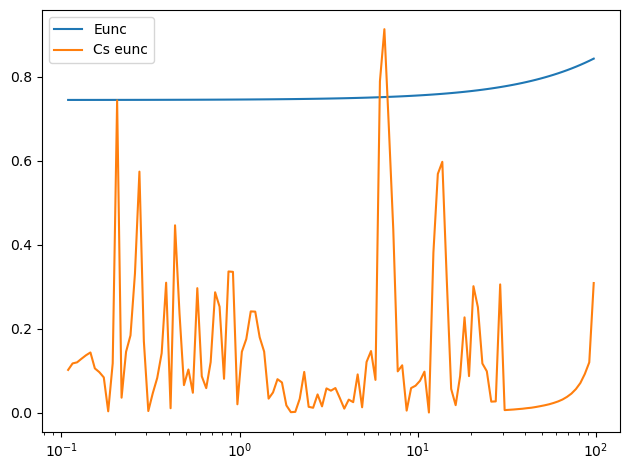

In [19]:
if forStandards:
# get energy uncertainties in energy
    cscov = DS6001_nfcs.cov_eunc
    Euncov = zeros([dim,dim],dtype=float)
 

    deriv_nucdata = [ 1.25637277e+00,1.30325162e+00,1.28532292e+00,1.32141657e+00\
,1.35078354e+00,1.38274533e+00,9.78868172e-01,8.43702161e-01\
,7.24607591e-01,2.98450436e-02,8.63479118e-01,5.48227541e+00\
,2.56286659e-01,9.94096148e-01,1.19750929e+00,2.10045127e+00\
,3.52172721e+00,-1.00492161e+00,2.42151333e-02,2.44470355e-01\
,4.14791541e-01,6.65702916e-01,1.39267311e+00,-4.72348433e-02\
,1.85026827e+00,9.50598783e-01,2.55428594e-01,3.80959368e-01\
,1.65834092e-01,9.89815163e-01,2.79225793e-01,1.76907138e-01\
,3.47417491e-01,7.91509794e-01,6.71039781e-01,-2.05557875e-01\
,-7.93468860e-01,-7.21993877e-01,-4.06137850e-02,2.74917374e-01\
,3.19541630e-01,4.22081225e-01,4.04709314e-01,2.91695336e-01\
,2.26821735e-01,-4.94540410e-02,-6.71497401e-02,-1.03709138e-01\
,-8.76071354e-02,-2.04445787e-02,-1.79257652e-03,-2.42033496e-03\
,-3.21965042e-02,-8.79046406e-02,-1.21552908e-02,9.68735618e-03\
,3.31639545e-02,1.10661565e-02,3.94682271e-02,3.40713689e-02\
,3.58920416e-02,2.02267411e-02,5.44030480e-03,1.63129739e-02\
,1.24397909e-02,4.21556991e-02,5.82599576e-03,5.00126356e-02\
,5.83254528e-02,2.98788550e-02,-2.73037371e-01,-2.77883947e-01\
,-1.83495420e-01,-1.06013226e-01,-2.22438226e-02,-2.37439898e-02\
,1.07727277e-03,1.10305485e-02,1.15156832e-02,1.28946473e-02\
,1.57825878e-02,1.30760211e-04,-5.37347647e-02,-7.36924431e-02\
,-6.95548936e-02,-3.35034880e-02,-5.51659949e-03,-1.66586875e-03\
,7.61423869e-03,1.87202826e-02,6.86156478e-03,-2.23255663e-02\
,-1.71343592e-02,-7.40709406e-03,-5.82753901e-03,-1.45828137e-03\
,-1.43076135e-03,-1.48818379e-02,-3.01222143e-04,-3.11973733e-04\
,-3.23982426e-04,-3.37445235e-04,-3.52671887e-04,-3.69966183e-04\
,-3.89701919e-04,-4.12389612e-04,-4.38626324e-04,-4.69228796e-04\
,-5.05261829e-04,-5.48207656e-04,-6.00004273e-04,-6.63144138e-04\
,-7.41543723e-04,-8.40970305e-04,-9.69727451e-04,-1.14120189e-03\
,-1.37783949e-03,-1.71857522e-03,4.15918970e-03]


    for index1 in arange(0,dim):
        for index2 in arange(0,dim):
            Euncov[index1,index2]=cscov[index1,index2]*\
            Data[index1]*Data[index2]/\
            (Einc[index1]*Einc[index2]*deriv_nucdata[index1]*deriv_nucdata[index2])
        

    Euncrelunc = sqrt(diag(Euncov))
    plt.semilogx(Einc,Euncrelunc)
    plt.semilogx(Einc,sqrt(diag(cscov)))
    plt.legend(['Eunc','Cs eunc'])

In [23]:
if forStandards:
    GMAnewnumber='6001'
    year = '2021'
    authors = 'NIFFTE TPC'
    journal = 'J,NDS,178,p.1(2021)'

    uncertainty_descriptor = ['UNCERTAINTIES',
                          '1 Energy Unc. calculated from 2.75ns (FWHM) and 3mm TOF length unc. (TOF length 8.059m)',\
                          '3 Statistical Unc.','4 Particle Identification unc.','5 Pu-239 wrap around and thermal background unc.',\
                          '6 Residual Detector Efficiency Unc.','7 Impurity Unc.', \
                          '8 Beam-target overlap and non-uniformity unc.',\
                          '9 Attenuation unc.']
    abc_components = ones([11,3],dtype=float)*0.5
    abc_components[0,:] = [0.99, 0.01,0.5]
    abc_components[1:3,:] = zeros([2,3],dtype=float)
    abc_components[3,:] = [0.1, 0.9,0.01]
    abc_components[4,:] = [0.8, 0.2,0.99]
    abc_components[5,:] = [0.0, 1.0,0.01]
    abc_components[6,:] = [0.35, 0.65,0.8]
    abc_components[7,:] = [0.0, 1.0,0.01]


    uncertainties = zeros([dim,12],dtype=float)
    uncertainties[:,:7] = array([statunc,deteffunc1,sqrt(background**2.0+thermalbckgrd**2.0),\
                           deteffunc2,impurity,overlap,attenuation]).transpose()

    normalizationunc = [0,0.0,0.0,0.0,0.0,\
                    0.0,0.0,0.0,0.0,0.0]

    controlnumber = [0,0,9,1,1,1,1,1,1,0,0]

    data = {'einc': Einc, 'einc_unit': 'MeV', 'values':Data, 'values_unit': "none" }
    Enrsl = zeros(dim,dtype=float)
    Eunc = Euncrelunc
    abs_shape = 'shape'

In [25]:
if forStandards:
    import WriteGMAOutput as WGMA
    output = WGMA.WriteGMAOutput(GMAnewnumber,year,authors,journal,general_info,uncertainty_descriptor,data,reference,\
                     abs_shape,abc_components,Eunc,Enrsl,uncertainties,controlnumber,normalizationunc)